Random Forest R2 Score: 0.7737


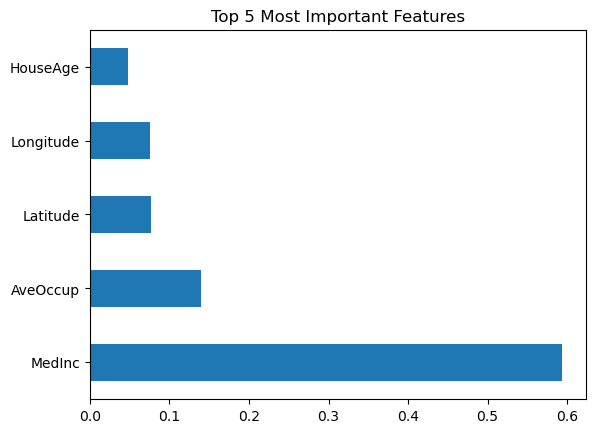

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2,
random_state=42)
# 2. Initialize the Forest
# n_estimators = number of trees in the forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# 3. Train
rf_model.fit(X_train, y_train)
# 4. Evaluate
predictions = rf_model.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(y_test, predictions):.4f}")

# Get importance scores
importances = rf_model.feature_importances_
feature_names = data.feature_names
# Create a Series for easy plotting
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Most Important Features")
plt.show()

In [2]:
import time

tree_counts = [10, 50, 200]

results = []

for n in tree_counts:
    start = time.time()
    
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    end = time.time()
    
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    
    results.append([n, r2, end - start])

import pandas as pd

df_results = pd.DataFrame(results, columns=["Trees", "R2 Score", "Training Time"])
print(df_results)

   Trees  R2 Score  Training Time
0     10  0.783104       2.635324
1     50  0.803651      12.016846
2    200  0.806186      49.458722


## Reflection

By increasing the number of trees in our Random Forest model, there is a definite rise in accuracy in the initial stages because of increased stability and decreased variance.
However, at some point, diminishing returns come into play because even though accuracy rises with the addition of more trees, the rise is very marginal, but computational costs shoot up significantly.
Thus, it is necessary to maintain the right balance between accuracy and computational costs while deciding on the number of trees to use.